In [1]:
# os 환경 변수 GEMINI API KEY 입력
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langgraph.graph import StateGraph, START, END

/Users/dohyunkim/Documents/langchain-study/langgraph/.venv/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


[Workflow 공식문서](https://docs.langchain.com/oss/python/langgraph/workflows-agents#orchestrator-worker)

# Routing

## Model 정의

In [3]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano")

## State 정의

In [4]:
from typing import TypedDict

class SupportState(TypedDict):
    query: str          # 고객 질문
    category: str       # 라우터가 분류한 카테고리
    response: str       # 전문가의 답변

In [5]:
from typing import Literal
from pydantic import BaseModel, Field

class RouteDecision(BaseModel):
    category: Literal['billing', 'technical', 'shipping', 'general'] = Field(
        description='고객 문의 내용을 분석하여 적절한 부서를 선택하세요'
    )


In [6]:
router_llm = model.with_structured_output(RouteDecision)

## Node 정의

In [7]:
# [Manager] router 노드
def router_node(state: SupportState):
    query = state["query"]
    print(f"\n--- [Router] 문의 분석 중: '{query}' ---")

    decision = router_llm.invoke(query) # LLM이 문맥을 읽고 카테고리를 결정함 (Rule-based가 아님!)


    print(f"   -> 분류 결과: {decision.category.upper()} 부서로 연결합니다.")
    return {"category": decision.category}

In [8]:
# [Expert A] 결제/환불 담당
def billing_expert(state: SupportState):
    print("--- [Billing Expert] 결제 전문가가 답변 작성 중 ---")
    prompt = f"당신은 결제 및 환불 전문가입니다. 다음 문의에 대해 정중하게 답변하세요: {state['query']}"
    msg = model.invoke(prompt)
    return {"response": msg.content}

# [Expert B] 기술 지원 담당
def technical_expert(state: SupportState):
    print("--- [Tech Expert] 기술 지원 엔지니어가 분석 중 ---")
    prompt = f"당신은 IT 엔지니어입니다. 다음 기술 문제에 대해 해결책을 제시하세요: {state['query']}"
    msg = model.invoke(prompt)
    return {"response": msg.content}

# [Expert C] 배송 담당
def shipping_expert(state: SupportState):
    print("--- [Shipping Expert] 물류 담당자가 배송 조회 중 ---")
    prompt = f"당신은 배송 관리자입니다. 다음 배송 문의에 대해 답변하세요: {state['query']}"
    msg = model.invoke(prompt)
    return {"response": msg.content}

# [Expert D] 일반 상담
def general_expert(state: SupportState):
    print("--- [General] 일반 상담원이 답변 중 ---")
    msg = model.invoke(f"다음 문의에 친절하게 답변하세요: {state['query']}")
    return {"response": msg.content}

## 그래프 생성

In [9]:
workflow = StateGraph(SupportState)

# 노드 등록
workflow.add_node("router_node", router_node)
workflow.add_node("billing_expert", billing_expert)
workflow.add_node("technical_expert", technical_expert)
workflow.add_node("shipping_expert", shipping_expert)
workflow.add_node("general_expert", general_expert)

# 엣지 연결
workflow.add_edge(START, "router_node")

In [10]:
# 조건부 엣지를 위한 함수
def route_to_expert(state: SupportState):
    category = state['category']

    if category == 'billing':
        return 'billing_expert'
    elif category == 'technical':
        return 'technical_expert'
    elif category == 'shipping':
        return 'shipping_expert'
    else :
        return 'general_expert'

In [11]:
workflow.add_conditional_edges(
    'router_node',
    route_to_expert,
    ['billing_expert', 'technical_expert', 'shipping_expert', 'general_expert']

)

In [12]:
workflow.add_edge('billing_expert', END)
workflow.add_edge('technical_expert', END)
workflow.add_edge('shipping_expert', END)
workflow.add_edge('general_expert', END)

In [13]:
app = workflow.compile()

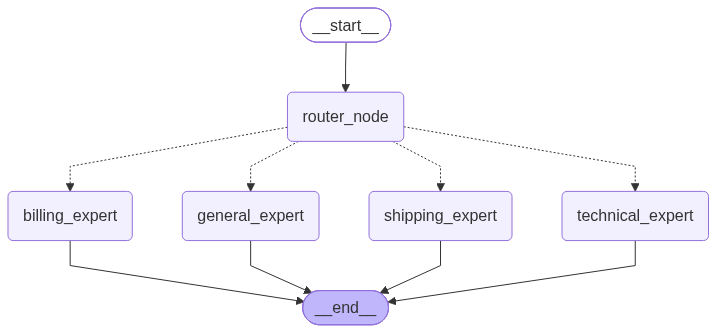

In [14]:
app

## 실행

In [15]:
app.invoke({"query": "지난달 요금이 두 번 빠져나갔어요. 확인해주세요."})


--- [Router] 문의 분석 중: '지난달 요금이 두 번 빠져나갔어요. 확인해주세요.' ---
   -> 분류 결과: BILLING 부서로 연결합니다.
--- [Billing Expert] 결제 전문가가 답변 작성 중 ---


{'query': '지난달 요금이 두 번 빠져나갔어요. 확인해주세요.',
 'category': 'billing',
 'response': '안녕하세요. 불편을 겪게 해드려 정말 죄송합니다. 지난달 요금이 두 번 청구된 건 신속하게 확인하고 환불 조치를 도와드리겠습니다.\n\n조사를 정확히 진행하기 위해 아래 정보를 알려주시면 더 빠르게 처리할 수 있습니다.\n- 계정에 등록된 이메일 주소나 사용자 ID\n- 두 번 청구된 날짜와 대략적인 시간 범위\n- 각 건의 청구 금액\n- 결제 수단의 마지막 4자리(전체 카드번호는 제공하지 않아도 됩니다)\n- 거래 ID나 영수증 번호가 있다면 함께 첨부\n- 은행 명과 화면에 보이는 금액이 보이는 스크린샷(가능하다면)\n\n확인 절차 및 예상 소요\n- 저희 결제 시스템 로그와 거래 기록을 확인합니다.\n- 중복 청구 여부를 판별하고, 중복으로 확인되면 해당 건을 환불 처리하거나 차기 청구에서 크레딧으로 반영합니다.\n- 처리 완료 후 결과를 고객님께 안내드립니다. 일반적으로 3-5 영업일 이내에 안내드리지만 상황에 따라 다를 수 있습니다.\n- 필요 시 재발 방지 점검 및 향후 청구 주기 조정도 함께 안내드립니다.\n\n다른 도움이나 문의가 더 있으시면 언제든지 알려주세요. 필요한 정보를 받는 즉시 즉시 조사를 시작하겠습니다. 감사합니다.'}

In [16]:
app.invoke({"query": "API 연결할 때 404 에러가 자꾸 떠요."})


--- [Router] 문의 분석 중: 'API 연결할 때 404 에러가 자꾸 떠요.' ---
   -> 분류 결과: TECHNICAL 부서로 연결합니다.
--- [Tech Expert] 기술 지원 엔지니어가 분석 중 ---


{'query': 'API 연결할 때 404 에러가 자꾸 떠요.',
 'category': 'technical',
 'response': '다음은 API 연결에서 404 오류가 자꾸 발생할 때의 실전 해결 가이드입니다. 404는 “해당 자원(path)이 서버에 없다”는 뜻이므로, 주로 URL/경로 문제나 리소스 존재 여부, 환경 차이에서 발생합니다. 아래 순서대로 점검해 보세요.\n\n1) 기본 원인 가정 확인\n- 404의 일반적 원인: 잘못된 URL(호스트/프로토콜/경로), API 버전 불일치, 경로에 필요한 자원-id가 없거나 잘못됨, 잘못된 HTTP 메서드로 요청, 환경(prod/stage) 차이로 인한 경로 차이, 인증/권한으로 인해 실제 자원에 접근 불가를 숨기려 404를 반환하도록 설정된 경우 등.\n- 먼저 “요청 URL이 정확한가”를 확실히 확인하는 것이 가장 흔한 원인입니다.\n\n2) 실전 체크리스트\n- 요청 URL 확인\n  - 문서의 예시 URL과 실제 요청 URL이 완전히 일치하는가? 예: https://api.example.com/v1/users/123 vs /v2/users/123\n  - 버전 경로(/v1, /v2 등)가 맞는가?\n  - 경로에 대소문자 차이가 있는가? URL은 대소문자 구분될 수 있습니다.\n  - 트레일링 슬래시(/)의 여부가 문제를 일으키나? 일부 서버는 슬래시 차이에 민감합니다.\n- 경로 구성 요소 점검\n  - 동적 파라미터(id 등)가 올바르게 채워졌는가? 필요한 경우 URL 인코딩이 되어 있는가?\n  - 경로에 누락된 필수 부분이 없는가? 예: /api/v1/users/{id}/profile처럼 자원이 필요할 때 id가 없으면 404 가능성 증가.\n- HTTP 메서드 확인\n  - 문서에서 해당 경로가 GET/POST/PUT/DELETE 중 무엇을 허용하는지 확인. 잘못된 메서드면 404 대신 405가 더 흔합니다만, 일부 API는 404를 반환하기도 합니다.\n- 인증/권한 여부 점검\n  

In [17]:
app.invoke({"query": "주문한 노트북 언제 도착하나요?"})


--- [Router] 문의 분석 중: '주문한 노트북 언제 도착하나요?' ---
   -> 분류 결과: SHIPPING 부서로 연결합니다.
--- [Shipping Expert] 물류 담당자가 배송 조회 중 ---


{'query': '주문한 노트북 언제 도착하나요?',
 'category': 'shipping',
 'response': '도와드리겠습니다. 정확한 도착일(ETA)을 알려면 주문 정보가 필요합니다. 아래 정보를 알려주시면 시스템에서 현재 위치와 예상 도착일을 바로 확인해 드리겠습니다.\n\n필요 정보\n- 주문번호\n- 운송장 번호(tracking number) 또는 배송 방법\n- 수령인 이름\n- 배송지 주소(필요 시)\n\n원하신다면 제가 바로 조회해 답변 형태로 정리해 드리겠습니다. 아래에 바로 보낼 수 있는 두 가지 템플릿을 드립니다.\n\n템플릿 A: 고객에게 보낼 답변 예시\n- 제목/인사: 고객님 안녕하세요, 주문하신 노트북의 도착 예정일을 확인해 안내 드립니다.\n- 내용: 주문번호 [주문번호]의 현재 배송 상태는 [상태]이며, 예상 도착일은 [예상 도착일]입니다. 배송 추적 번호: [트래킹번호]. 상세 추적 링크: [링크].\n- 추가 안내: 배송 상황에 따라 일정이 변동될 수 있습니다. 변경 사항이 생기면 즉시 알려 드리겠습니다. 필요하신 경우 배송 주소를 다시 확인해 드리겠습니다: [주소].\n\n템플릿 B: 내부 확인용 메모 (상황 요약)\n- 주문번호: [주문번호]\n- 트래킹 번호: [트래킹번호]\n- 현재 상태: [상태: 예: 배송 중/예비 배송일 등]\n- 예상 도착일: [YYYY-MM-DD]\n- 비고: [통관 이슈, 기상 영향 여부, 배송지 변경 요청 등 필요한 메모]\n\n질문이나 필요한 정보가 아직 없으시면, 제가 바로 조회를 시작할 수 있도록 주문번호를 알려 주세요. 또한 현재 진행 중인 배송의 예상 도착일을 즉시 알려드리겠습니다.'}